In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("india_job_market_2024_2026.csv")
df.head()
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   str    
 1   Job_Title           5000 non-null   str    
 2   Company             5000 non-null   str    
 3   Company_Type        5000 non-null   str    
 4   Industry            5000 non-null   str    
 5   City                5000 non-null   str    
 6   Location_Tier       5000 non-null   str    
 7   Experience_Level    5000 non-null   str    
 8   Job_Type            5000 non-null   str    
 9   Work_Mode           5000 non-null   str    
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   str    
 12  Education_Required  5000 non-null   str    
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   float64
 16  Date_Posted      

Index(['Job_ID', 'Job_Title', 'Company', 'Company_Type', 'Industry', 'City',
       'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode',
       'Salary_LPA', 'Skills_Required', 'Education_Required', 'Openings',
       'Applicants', 'Company_Rating', 'Date_Posted'],
      dtype='str')

#Handling missing values

In [4]:
df.isnull().sum()
df.dropna()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,IND2029995,Backend Developer,BEL,PSU/Govt,Media & Entertainment,Jaipur,Tier 2,Fresher (0-1 yr),Full-Time,Hybrid,4.5,"PostgreSQL, Java, Django, MongoDB, Docker",B.Tech/B.E.,2,72,4.2,2025-03-11
4996,IND2029996,React Developer,Google,MNC,Manufacturing,Remote,Remote,Fresher (0-1 yr),Full-Time,Remote,4.3,"TypeScript, React, JavaScript, Redux, Next.js",B.Tech/B.E.,1,76,4.0,2024-12-30
4997,IND2029997,QA Engineer,BHEL,PSU/Govt,FinTech,Remote,Remote,Mid (3-6 yrs),Contract,Remote,10.5,"Python, API Testing, Manual Testing, JIRA",B.Tech/B.E.,2,72,3.1,2026-02-23
4998,IND2029998,Frontend Developer,Byju's,Indian Unicorn,FinTech,Remote,Remote,Mid (3-6 yrs),Internship,On-Site,1.6,"Tailwind CSS, Figma, React, JavaScript, TypeSc...",BCA,3,187,3.9,2025-04-26


#top hiring cities

Text(0.5, 1.0, 'Top Hiring Cities')

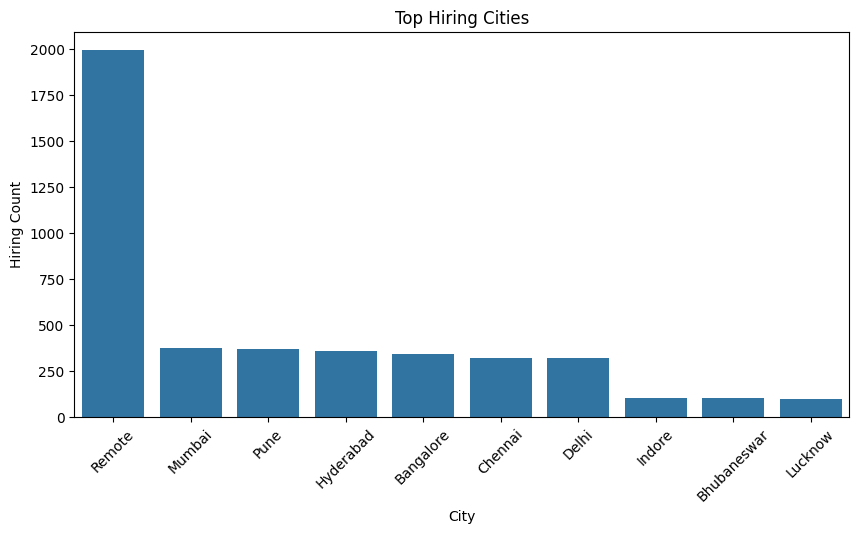

In [5]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Hiring Count")
plt.title("Top Hiring Cities")

#Most demanded skills

In [6]:
top_skills = df['Skills_Required'].value_counts().head(10)
print(top_skills)

Skills_Required
JavaScript, Next.js, TypeScript                  3
SQL, JIRA, Agile                                 3
Next.js, TypeScript, React                       3
Next.js, JavaScript, React                       3
Redis, MongoDB, FastAPI                          3
Power BI, SQL, Data Visualization                3
Next.js, Tailwind CSS, JavaScript, TypeScript    3
Tailwind CSS, TypeScript, Next.js                3
Kotlin, Java, REST APIs                          2
Agile, Power BI, Requirements Gathering          2
Name: count, dtype: int64


#Highest paying roles

Text(0, 0.5, 'Average Salary')

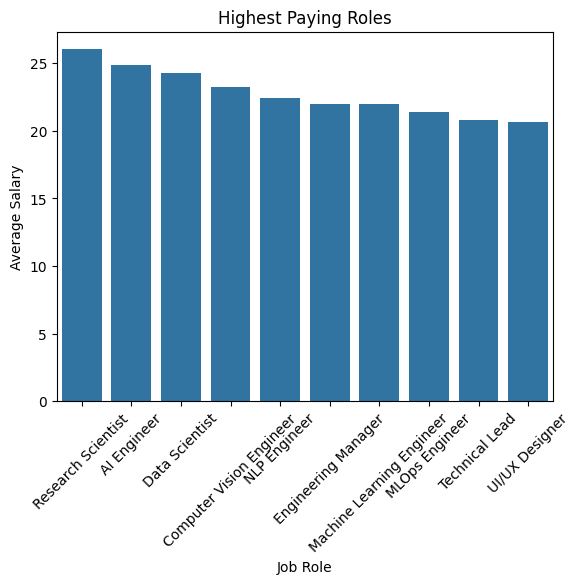

In [7]:
highest_roles = df.groupby('Job_Title')['Salary_LPA'].mean()
highest_roles = highest_roles.sort_values(ascending=False).head(10)
highest_roles
sns.barplot(
    x=highest_roles.index,
    y=highest_roles.values
)
plt.xticks(rotation=45)
plt.title("Highest Paying Roles")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")


#Hiring Trend By year

Text(0.5, 1.0, 'Hiring Trend By Year')

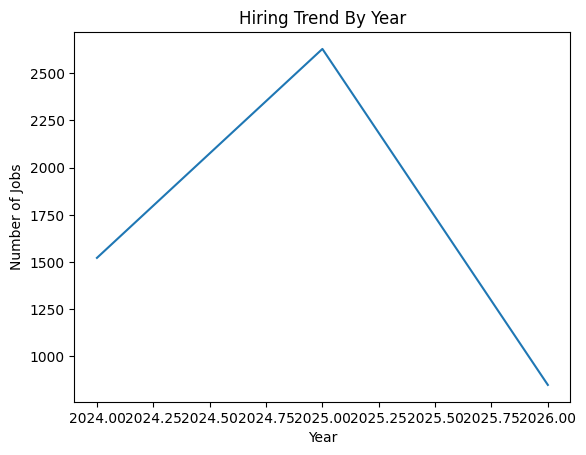

In [8]:
df['Year'] = pd.to_datetime(df['Date_Posted']).dt.year
year_trend = df['Year'].value_counts().sort_index()
year_trend
sns.lineplot(
    x=year_trend.index,
    y=year_trend.values,
)
plt.xlabel("Year")
plt.ylabel("Number of Jobs")
plt.title("Hiring Trend By Year")

#Salry Distribution Analysis

Text(0.5, 0, 'Salary')

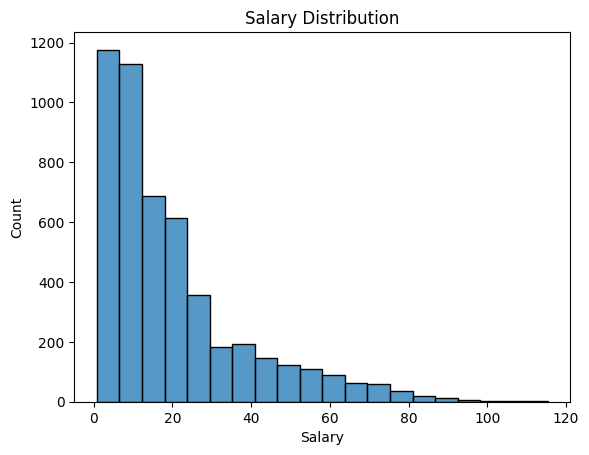

In [9]:
sns.histplot(df['Salary_LPA'],bins=20)
plt.title("Salary Distribution")
plt.xlabel('Salary')

#Analyze relationship between:
#Experience vs Salary

Text(0.5, 1.0, 'Experince vs Salary')

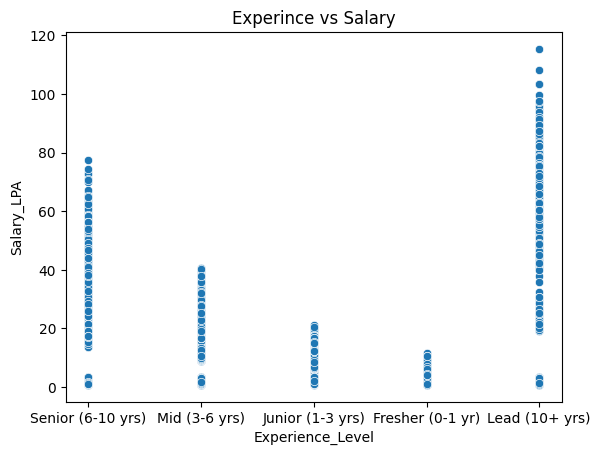

In [10]:
sns.scatterplot(
    x='Experience_Level',
    y='Salary_LPA',
    data = df
)
plt.title("Experince vs Salary")

#Remote jobs vs On-site jobs

Text(0.5, 1.0, 'Remote jobs vs On-site Jobs')

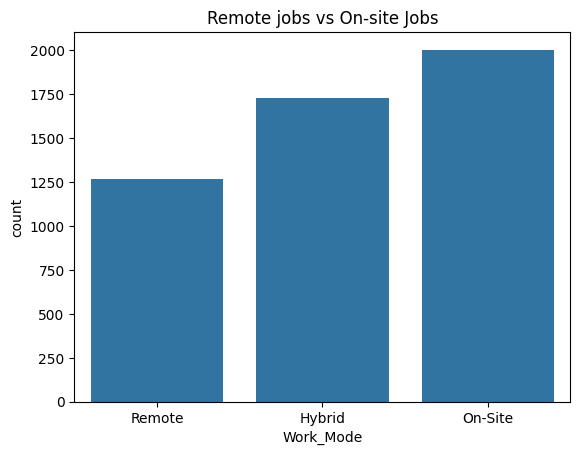

In [11]:
sns.countplot(
    x='Work_Mode',
    data=df
)
plt.title("Remote jobs vs On-site Jobs")

#Skill demand vs Salary

Text(0.5, 1.0, 'Skill Demand vs Salary')

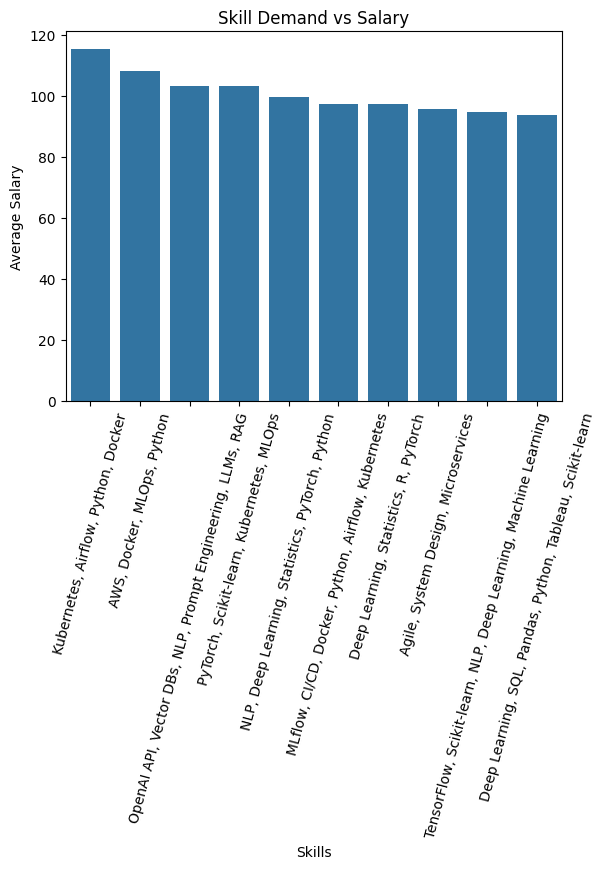

In [15]:
skill_salary = df.groupby('Skills_Required')['Salary_LPA'].mean()
skill_salary = skill_salary.sort_values(ascending=False).head(10)
sns.barplot(
    x=skill_salary.index,
    y=skill_salary.values
)
plt.xticks(rotation=75)
plt.xlabel("Skills")
plt.ylabel("Average Salary")
plt.title("Skill Demand vs Salary")


#Heatmap->

Text(0.5, 1.0, 'Correlation Heatmap')

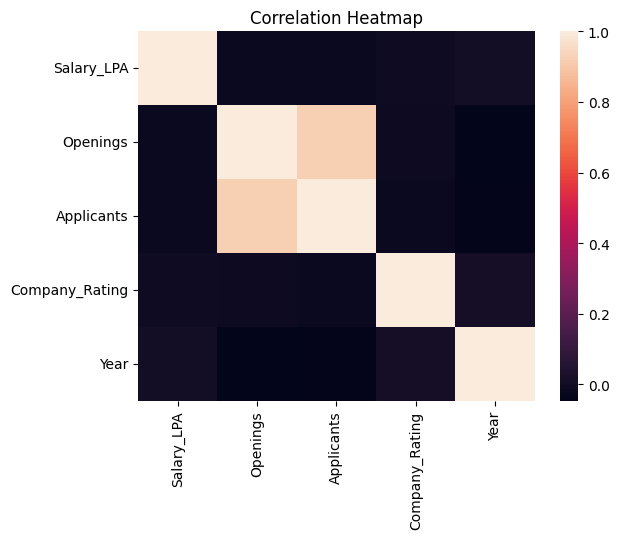

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)
plt.title("Correlation Heatmap")

#Boxplot->

Text(0.5, 1.0, 'Salary Distribution by Job Role')

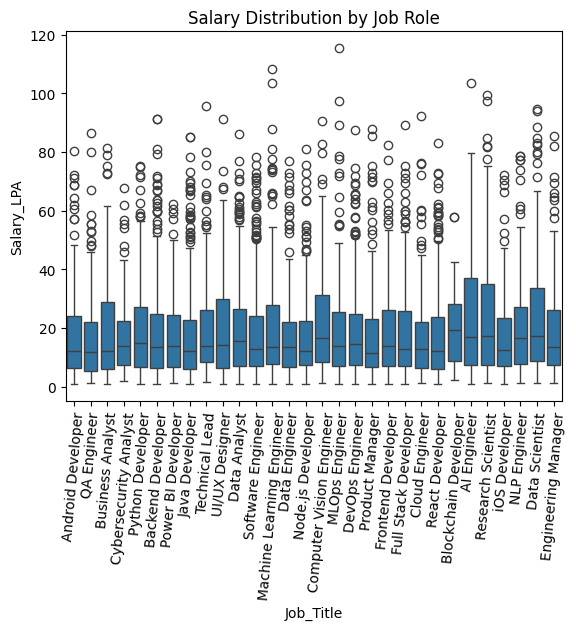

In [14]:
sns.boxplot(
    x='Job_Title',
    y='Salary_LPA',
    data=df
)
plt.xticks(rotation=85)
plt.title("Salary Distribution by Job Role")